In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install lpips

In [3]:
import os
from PIL import Image
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F
import torch
import torch.optim as optim
from torchvision.models import vgg16
import lpips
import matplotlib.pyplot as plt
import time
import numpy as np
import math
import sys

In [4]:
REPO_DIR = '/content/Texture_synthesis'
os.chdir('/content')

if not os.path.exists(REPO_DIR):
  !git clone https://github.com/ValentinaEmili/Texture-synthesis.git Texture_synthesis

if REPO_DIR not in sys.path:
  sys.path.append(REPO_DIR)

Cloning into 'Texture_synthesis'...
remote: Enumerating objects: 796, done.
remote: Counting objects: 100% (145/145), done.
remote: Compressing objects: 100% (121/121), done.
remote: Total 796 (delta 72), reused 9 (delta 9), pack-reused 651 (from 2)
Receiving objects: 100% (796/796), 92.83 MiB | 14.58 MiB/s, done.
Resolving deltas: 100% (359/359), done.


In [5]:
!pip install import-ipynb -q
import import_ipynb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 123.3 MB/s eta 0:00:00


In [ ]:
def merge_files(input_files, output_file):
  out_file_path = os.path.join(path_labels, output_file)

  with open(out_file_path, mode='w', encoding='utf-8') as out_f:
    for file in input_files:
      in_file_path = os.path.join(path_labels, file)

      with open(in_file_path, mode='r', encoding='utf-8') as in_f:
        for line in in_f:
          line = line.strip()
          if line:
            out_f.write(line + '\n')

merge_files(['train1.txt', 'train2.txt'], 'train_1_2.txt')
merge_files(['val1.txt', 'val2.txt'], 'val_1_2.txt')
merge_files(['test1.txt', 'test2.txt'], 'test_1_2.txt')

In [60]:
model_type = 'vq_vae'
#model_type = 'vq_gan'
#model_type = 'vq_gan_tt'

#split = '1'
#split = '2'
split = '1_2'

In [63]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if model_type == 'vq_vae':
  from Texture_synthesis.codebook.VQ_VAE import VQ_VAE
  generator = VQ_VAE().to(device)
  optimizer_gen = optim.Adam(generator.parameters(), lr=5e-5, betas=(0.9, 0.999))
  save_folder = f'/content/drive/MyDrive/DeepLearning/dtd/checkpoints/{model_type}'
  gen_save_path = os.path.join(save_folder, f"best_{split}.pth")
  size = 512
  batch_size = 16

elif model_type == 'vq_gan':
  from Texture_synthesis.codebook.VQGAN.VQGAN import VQGAN, Discriminator
  generator = VQGAN().to(device)
  discriminator = Discriminator().to(device)
  optimizer_gen = optim.Adam(generator.parameters(), lr=2e-4, betas=(0.5, 0.9))
  save_folder = f'/content/drive/MyDrive/DeepLearning/dtd/checkpoints/{model_type}'
  gen_save_path = os.path.join(save_folder, f"gen_best_{split}.pth")
  disc_save_path = os.path.join(save_folder, f"disc_best_{split}.pth")
  size = 512
  batch_size = 4

else:
  from Texture_synthesis.codebook.VQGAN.VQGAN_TT import VQGAN, Discriminator
  generator = VQGAN().to(device)
  discriminator = Discriminator().to(device)
  optimizer_gen = optim.Adam(generator.parameters(), lr=2e-4, betas=(0.5, 0.9))
  optimizer_disc = optim.Adam(discriminator.parameters(), lr=5e-5, betas=(0.5, 0.9))
  save_folder = '/content/drive/MyDrive/DeepLearning/dtd/checkpoints/vq_gan/taming_transformers'
  gen_save_path = os.path.join(save_folder, f"gen_best_{split}.pth")
  disc_save_path = os.path.join(save_folder, f"disc_best_{split}.pth")
  size = 256
  batch_size = 4

perceptual_loss_fn = lpips.LPIPS(net='vgg').to(device)

perceptual_loss_fn.eval()
for p in perceptual_loss_fn.parameters():
    p.requires_grad_(False)

train_file = 'train_' + split + '.txt'
val_file = 'val_' + split + '.txt'
test_file = 'test_' + split + '.txt'

Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]
Loading model from: /usr/local/lib/python3.13/dist-packages/lpips/weights/v0.1/vgg.pth


In [45]:
train_transform = transforms.Compose([
        transforms.Resize(size),
        transforms.RandomCrop(size),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
        ])

eval_transform = transforms.Compose([
        transforms.Resize(size),
        transforms.CenterCrop(size),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
        ])


class DTD_Dataset(Dataset):
    def __init__(self, root, file_list, transform=None, class_to_idx=None):
        self.root = root
        self.transform = transform

        with open(file_list, mode='r', encoding='utf-8') as f:
            self.files = [line.strip() for line in f if line.strip()]

        if class_to_idx is None:
          unique_classes = sorted({os.path.normpath(p).split(os.sep)[0] for p in self.files})
          self.class_to_idx = {class_name: i for i, class_name in enumerate(unique_classes)}
        else:
          self.class_to_idx = class_to_idx

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        relative_path = self.files[idx]
        image_path = os.path.join(self.root, relative_path)
        img = Image.open(image_path).convert('RGB')
        rel_norm = os.path.normpath(relative_path)
        string_label = rel_norm.split(os.sep, 1)[0]
        label = self.class_to_idx[string_label]

        if self.transform:
            img = self.transform(img)

        return img, label

In [65]:
path_images = "drive/MyDrive/DeepLearning/dtd/images"
path_labels = "drive/MyDrive/DeepLearning/dtd/labels"

train_dataset = DTD_Dataset(path_images, os.path.join(path_labels, train_file), train_transform)
class_to_idx = train_dataset.class_to_idx
val_dataset = DTD_Dataset(path_images, os.path.join(path_labels, val_file), eval_transform, class_to_idx=class_to_idx)
test_dataset = DTD_Dataset(path_images, os.path.join(path_labels, test_file), eval_transform, class_to_idx=class_to_idx)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

## Validation

In [68]:
def visual_validation(model, val_loader, device, show_imgs=True):
  model.eval()

  all_indices = []
  visual_samples = None
  total_loss, total_percept, total_recon, total_vq = 0.0, 0.0, 0.0, 0.0

  num_embeddings = model.vq.num_embeddings
  embedding_dim = model.vq.embedding_dim
  embeddings = model.vq.embeddings.weight

  with torch.no_grad():
    for batch_idx, (data, _) in enumerate(val_loader):
      data = data.to(device)
      data_recon, vq_loss, _, _ = model(data)

      visual_samples = (data.cpu(), data_recon.cpu())

      metric_data = F.interpolate(data, size=(256, 256), mode='bilinear', align_corners=False)
      metric_data_recon = F.interpolate(data_recon, size=(256, 256), mode='bilinear', align_corners=False)

      recon_loss = F.mse_loss(metric_data_recon, metric_data)                                           # reconstruction loss
      percept_loss = perceptual_loss_fn(metric_data_recon, metric_data).mean()                          # perceptual loss
      loss = percept_loss + vq_loss + recon_loss * 0.2

      total_recon += recon_loss.item()
      total_percept += percept_loss.item()
      total_vq += vq_loss.item()
      total_loss += loss.item()

      z = model.encoder(data)
      z_flattened = z.permute(0, 2, 3, 1).contiguous().view(-1, embedding_dim)

      distances = (torch.sum(z_flattened**2, dim=1, keepdim=True)
                    + torch.sum(embeddings**2, dim=1)
                    - 2 * torch.matmul(z_flattened, embeddings.t()))

      indices = torch.argmin(distances, dim=1)
      all_indices.append(indices.cpu())

  # percentage of used vectors
  encoding_indices = torch.cat(all_indices)
  unique_indices = torch.unique(encoding_indices)
  util_percen = len(unique_indices) / num_embeddings * 100

  # perplexity
  counts = torch.bincount(encoding_indices, minlength=num_embeddings).float()
  probs = counts / counts.sum()
  perplexity = torch.exp(-torch.sum(probs * torch.log(probs + 1e-10)))

  avg_loss = total_loss / len(val_loader)
  avg_recon = total_recon / len(val_loader)
  avg_percept = total_percept / len(val_loader)
  avg_vq = total_vq / len(val_loader)

  selection_score = avg_percept + 0.2 * avg_recon
  unique_vectors_used = (len(unique_indices) / num_embeddings) * 100

  # visual reconstruction plotting
  if (show_imgs):
    print(f"Perceptual Loss: {avg_percept:.4f}  \nReconstruction Loss: {avg_recon:.4f}  \nCodebook Loss: {avg_vq:.4f}")
    print(f"Unique Vectors Used: {unique_vectors_used:.4f}%  \nCodebook Utilization: {util_percen:.2f}%  \nCodebook Perplexity: {perplexity.item():.2f}")

    real_imgs, recon_imgs = visual_samples
    num_displayed_imgs = 8 #min(16, real_imgs.shape[0])

    fig, axes = plt.subplots(2, num_displayed_imgs, figsize=(num_displayed_imgs * 3, 6))

    for i in range(num_displayed_imgs):
      real_img = real_imgs[i].permute(1, 2, 0).numpy()
      recon_img = recon_imgs[i].permute(1, 2, 0).numpy()

      real_plot = ((real_img + 1) / 2).clip(0, 1)
      recon_plot = ((recon_img + 1) / 2).clip(0, 1)

      axes[0, i].imshow(real_plot)
      axes[0, i].set_title(f"original {i+1}")
      axes[0, i].axis('off')

      axes[1, i].imshow(recon_plot)
      axes[1, i].set_title(f"reconstructed {i+1}")
      axes[1, i].axis('off')

    plt.show()

  else:
    print(f"Val Loss: {avg_loss:.4f}  | Perceptual Loss: {avg_percept:.4f}  | Reconstruction Loss: {avg_recon:.4f}  | Codebook Loss: {avg_vq:.4f}")
    print(f"Unique Vectors Used: {unique_vectors_used:.4f}%  | Codebook Utilization: {util_percen:.2f}%  | Codebook Perplexity: {perplexity.item():.2f}")

  return selection_score, unique_vectors_used, perplexity.item()

## Training

In [ ]:
def calculate_adaptive_weight(recon_loss, g_loss, last_layer_weights):
    recon_grads = torch.autograd.grad(recon_loss, last_layer_weights, retain_graph=True, allow_unused=True)[0]
    g_grads = torch.autograd.grad(g_loss, last_layer_weights, retain_graph=True, allow_unused=True)[0]

    if recon_grads is None:
      recon_norm = torch.tensor(0., device=last_layer_weights.device)
    else:
      recon_norm = torch.norm(recon_grads)

    if g_grads is None:
      g_norm = torch.tensor(0., device=last_layer_weights.device)
    else:
      g_norm = torch.norm(g_grads)

    lambda_weight = recon_norm / (g_norm + 1e-4)
    lambda_weight = torch.clamp(lambda_weight, 0.0, 1e4).detach()
    return lambda_weight

In [ ]:
def set_requires_grad(model, requires_grad):
  for param in model.parameters():
    param.requires_grad = requires_grad

def train_step(generator, discriminator, perceptual_loss_fn, data, optimizer_g, optimizer_d, disc_start_step, current_global_step):
    # GENERATOR

    # disable discriminator gradients while training generator
    set_requires_grad(discriminator, False)

    optimizer_g.zero_grad()
    recon_batch, vq_loss, perplexity, active_codes = generator(data)
    recon_loss = F.mse_loss(recon_batch, data)
    percept_loss = perceptual_loss_fn(recon_batch, data).mean()

    # dynamic adaptive weight scheduling
    if current_global_step >= disc_start_step:
        fake_outputs = discriminator(recon_batch)
        g_loss = -fake_outputs.mean()   # hinge loss

        last_layer_weights = generator.decoder.block5.weight
        disc_weight = calculate_adaptive_weight(recon_loss + percept_loss, g_loss, last_layer_weights)

        gen_loss = vq_loss + recon_loss + percept_loss + (disc_weight * g_loss)
    else:
        gen_loss = vq_loss + recon_loss + percept_loss

    gen_loss.backward()
    optimizer_g.step()
    set_requires_grad(discriminator, True)

    # DISCRIMINATOR
    disc_loss = torch.tensor(0.0, device=data.device)
    if current_global_step >= disc_start_step:
        optimizer_d.zero_grad()

        real_outputs = discriminator(data)
        fake_outputs_d = discriminator(recon_batch.detach())

        loss_real = F.relu(1.0 - real_outputs).mean()
        loss_fake = F.relu(1.0 + fake_outputs_d).mean()

        disc_loss = 0.5 * loss_real + 0.5 * loss_fake
        disc_loss.backward()
        optimizer_d.step()

    return gen_loss.item(), disc_loss.item(), perplexity.item(), active_codes

In [38]:
def train_and_validation(
    generator, optimizer_gen,
    train_loader, val_loader, device, gen_save_path,
    discriminator=None, optimizer_disc=None, disc_save_path=None,
    best_val_score=float('inf'), disc_start_step=0, global_step=0, epochs=20, show_imgs=True):

  for epoch in range(39, epochs):

    generator.train()

    # VQGAN training
    if discriminator:
      discriminator.train()
      total_loss_gen, total_loss_disc = 0.0, 0.0

      for batch_idx, (data, _) in enumerate(train_loader):
        data = data.to(device)

        gen_loss, disc_loss = train_step(
                                    generator, discriminator, perceptual_loss_fn, data,
                                    optimizer_gen, optimizer_disc,
                                    disc_start_step, global_step
                                    )

        global_step += 1

        total_loss_gen += gen_loss
        total_loss_disc += disc_loss

      avg_gen_loss = total_loss_gen / len(train_loader)
      avg_disc_loss = total_loss_disc / len(train_loader)

      print(f"====> Epoch {epoch} Finished | Avg G-Loss: {avg_gen_loss:.4f} | Avg D-Loss: {avg_disc_loss:.4f}")

      val_score, unique_vectors_used, perplexity = visual_validation(generator, val_loader, device, show_imgs=show_imgs)

      if val_score < best_val_score:
        best_val_score = val_score
        print(f"New best epoch is epoch {epoch}\n")

        torch.save({
            'epoch': epoch,
            'model_state_dict': generator.state_dict(),
            'optimizer_state_dict': optimizer_gen.state_dict(),
        }, gen_save_path)

        torch.save({
            'epoch': epoch,
            'model_state_dict': discriminator.state_dict(),
            'optimizer_state_dict': optimizer_disc.state_dict(),
            'best_val_score': val_score,
            'unique_vectos_used_percentage': unique_vectors_used,
            'perplexity': perplexity,
            'global_step': global_step
        }, disc_save_path)

    # VQ-VAE training
    else:
      total_loss, total_percept, total_recon, total_vq = 0.0, 0.0, 0.0, 0.0

      for batch_idx, (data, _) in enumerate(train_loader):
          data = data.to(device)
          optimizer_gen.zero_grad()
          data_recon, vq_loss, _, _ = generator(data)                         # codebook loss

          data = F.interpolate(data, size=(256, 256), mode='bilinear', align_corners=False)
          data_recon = F.interpolate(data_recon, size=(256, 256), mode='bilinear', align_corners=False)

          recon_loss = F.mse_loss(data_recon, data)                                           # reconstruction loss
          percept_loss = perceptual_loss_fn(data_recon, data).mean()                          # perceptual loss
          loss = percept_loss + vq_loss + recon_loss * 0.2
          loss.backward()

          optimizer_gen.step()

          total_loss += loss.item()

          total_percept += percept_loss.item()
          total_recon += recon_loss.item()
          total_vq += vq_loss.item()

      train_loss = total_loss / len(train_loader)
      train_percept = total_percept / len(train_loader)
      train_recon = total_recon / len(train_loader)
      train_vq = total_vq / len(train_loader)

      print(f"====> Train Loss: {train_loss:.4f}  | Perceptual Loss: {train_percept:.4f}  | Reconstruction Loss: {train_recon:.4f}  | Codebook Loss: {train_vq:.4f}\n")

      val_score, unique_vectors_used, perplexity = visual_validation(generator, val_loader, device, show_imgs=False)

    if val_score < best_val_score:
      best_val_score = val_score
      print(f"New best epoch is epoch {epoch}\n")

      torch.save({
          'epoch': epoch,
          'model_state_dict': generator.state_dict(),
          'optimizer_state_dict': optimizer_gen.state_dict(),
          'best_val_score': val_score,
          'unique_vectors_used_percentage': unique_vectors_used * 100,
          'perplexity': perplexity
      }, gen_save_path)

In [ ]:
if model_type == 'vq_vae':
  train_and_validation(
      generator, optimizer_gen,
      train_loader, val_loader, device, gen_save_path,
      epochs=40, show_imgs=False)

elif model_type == 'vq_gan':
  train_and_validation(
      generator, optimizer_gen,
      train_loader, val_loader, device, gen_save_path,
      discriminator=discriminator, optimizer_disc=optimizer_disc, disc_save_path=disc_save_path,
      disc_start_step=800, epochs=30, show_imgs=False)

else:
  train_and_validation(
      generator, optimizer_gen,
      train_loader, val_loader, device, gen_save_path,
      discriminator=discriminator, optimizer_disc=optimizer_disc, disc_save_path=disc_save_path,
      disc_start_step=1000, epochs=20, show_imgs=False)

## Visual validation

In [66]:
checkpoint = torch.load(gen_save_path, weights_only=True)
generator.load_state_dict(checkpoint['model_state_dict'])

<All keys matched successfully>

### VQ-VAE

#### Split 1

Perceptual Loss: 0.4176  
Reconstruction Loss: 0.0645  
Codebook Loss: 2.8591
Unique Vectors Used: 25.5859%  
Codebook Utilization: 25.59%  
Codebook Perplexity: 37.03


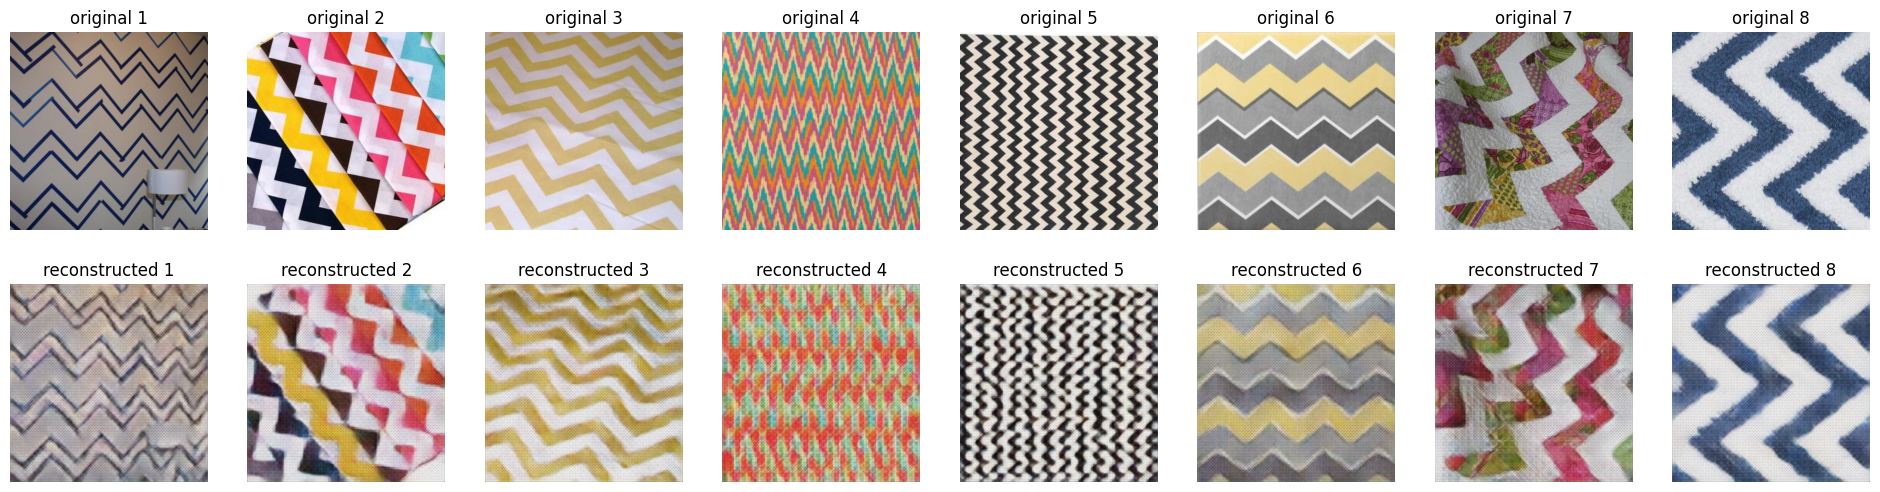

In [41]:
_, _, _ = visual_validation(generator, val_loader, device)

#### Split 2

Perceptual Loss: 0.5098  
Reconstruction Loss: 0.0873  
Codebook Loss: 1.8069
Unique Vectors Used: 43.5547%  
Codebook Utilization: 43.55%  
Codebook Perplexity: 28.79


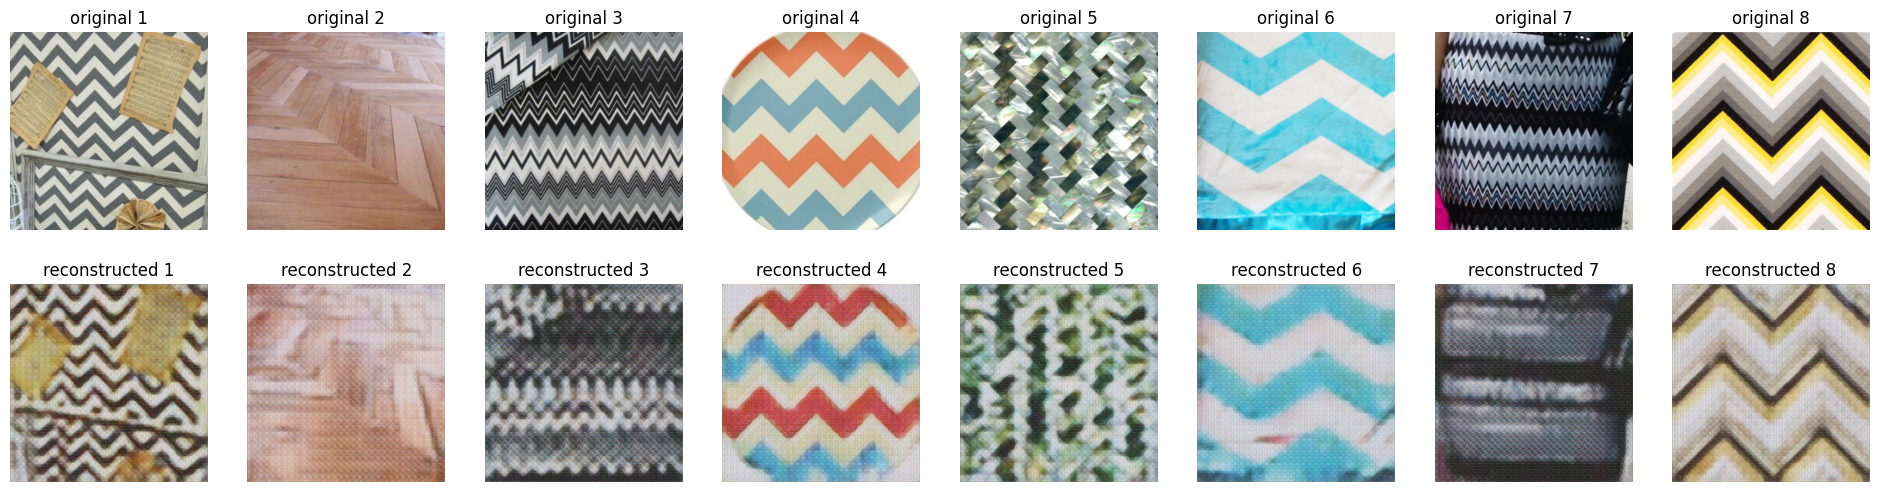

In [59]:
_, _, _ = visual_validation(generator, val_loader, device, show_imgs=True)

#### Split 1 and 2

Perceptual Loss: 0.4428  
Reconstruction Loss: 0.0707  
Codebook Loss: 2.7311
Unique Vectors Used: 35.7422%  
Codebook Utilization: 35.74%  
Codebook Perplexity: 34.04


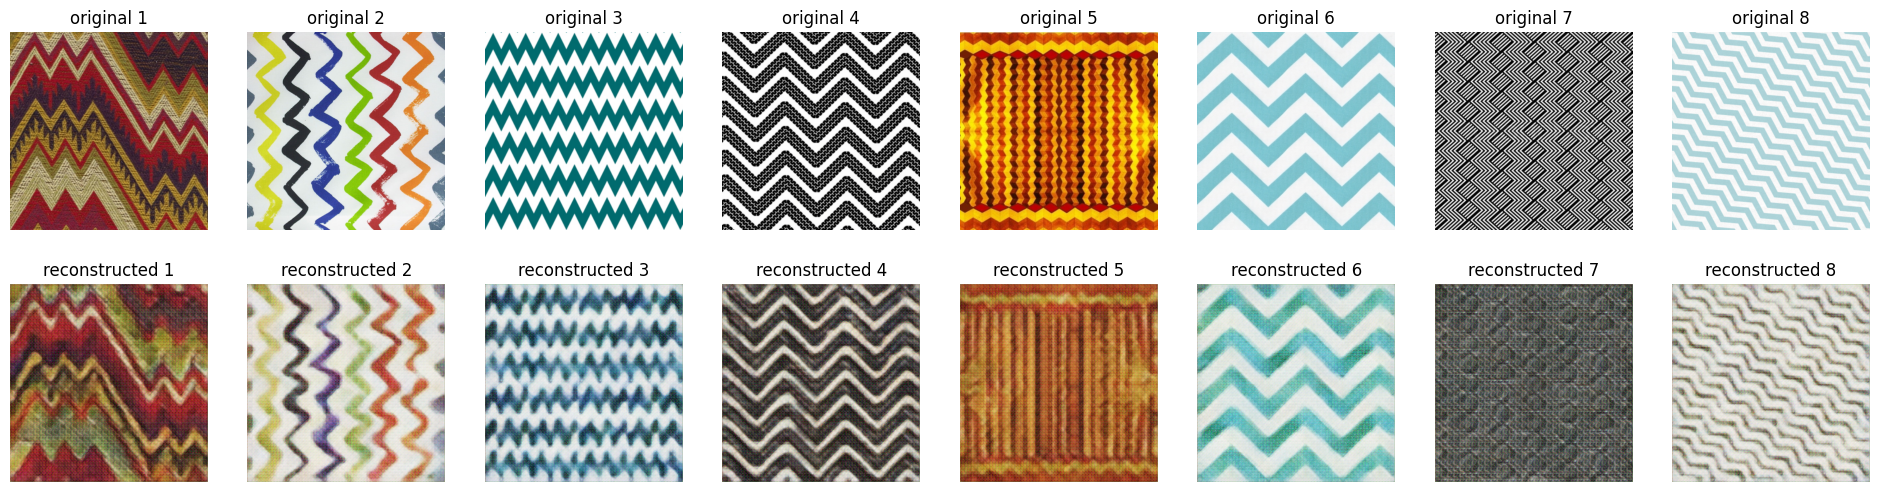

In [69]:
_, _, _ = visual_validation(generator, val_loader, device, show_imgs=True)

### VQGAN

#### Split 1

#### Split 2

#### Split 1 and 2

### VQGAN (Taming Transformers)

#### Split 1

#### Split 2

#### Split 1 and 2